<a href="https://colab.research.google.com/github/HeyWinTomsy/MN/blob/main/%D0%9B%D0%90%D0%912_2_%D0%90%D0%BD%D1%82%D1%80%D0%BE%D0%BF%D0%BE%D0%B2_%D0%A4%D0%86%D0%A23_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2_2. Був присутнім на парі

---



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

!wget -q -O amazon.zip https://www.kaggle.com/api/v1/datasets/download/sootersaalu/amazon-top-50-bestselling-books-2009-2019
with zipfile.ZipFile("amazon.zip", "r") as zip_ref:
    zip_ref.extractall("amazon_data")

df = pd.read_csv("amazon_data/bestsellers with categories.csv")
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


# Завдання 1

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [2]:
df.head(5)

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


2.	Визначити розмір датасета.

In [24]:
df.shape[0]
df.shape[1]
df.shape

(550, 7)

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [4]:
df = df[["Name", "Author", "User Rating", "Reviews", "Price", "Year", "Genre"])
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [25]:
print("Кількість пропусків:")
print(df.isnull().sum())

df["User Rating"] = df["User Rating"].fillna(df["User Rating"].mean())
df["Reviews"] = df["Reviews"].fillna(df["Reviews"].mean())
df["Price"] = df["Price"].fillna(df["Price"].mean())
df["Year"] = df["Year"].fillna(df["Year"].median())
df["Genre"] = df["Genre"].fillna(df["Genre"].mode()[0])
df["Author"] = df["Author"].fillna("Невідомий автор")
df["Name"] = df["Name"].fillna("Невідома книга")

print("\nПропуски після обробки:")
print(df.isnull().sum())

Кількість пропусків:
Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64

Пропуски після обробки:
Name           0
Author         0
User Rating    0
Reviews        0
Price          0
Year           0
Genre          0
dtype: int64


5. Ще раз вивести датасет

In [6]:
df.head(10)

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,12643,11,2011,Fiction
6,A Game of Thrones / A Clash of Kings / A Storm...,George R. R. Martin,4.7,19735,30,2014,Fiction
7,A Gentleman in Moscow: A Novel,Amor Towles,4.7,19699,15,2017,Fiction
8,"A Higher Loyalty: Truth, Lies, and Leadership",James Comey,4.7,5983,3,2018,Non Fiction
9,A Man Called Ove: A Novel,Fredrik Backman,4.6,23848,8,2016,Fiction


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [26]:
print("Кількість дублікатів:", df.duplicated().sum())
df = df.drop_duplicates()
print("Кількість рядків після видалення дублікатів:", len(df))

Кількість дублікатів: 0
Кількість рядків після видалення дублікатів: 550


7.	Вивести описову статистику датасету describe()

In [27]:
df.describe()

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [28]:
comparison = df[["Price", "User Rating"]].describe().loc[["mean", "50%", "min", "max"]]
comparison

,Price,User Rating
mean,13.1,4.618364
50%,11.0,4.700000
min,0.0,3.300000
max,105.0,4.900000


In [29]:
df.groupby("Genre")[["Price", "User Rating", "Reviews"]].mean()

,Price,User Rating,Reviews
Genre,,,
Fiction,10.850000,4.648333,15683.791667
Non Fiction,14.841935,4.595161,9065.145161


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [30]:
corr = df[["User Rating", "Reviews", "Price", "Year"]].corr()

corr

,User Rating,Reviews,Price,Year
User Rating,1.000000,-0.001729,-0.133086,0.242383
Reviews,-0.001729,1.000000,-0.109182,0.263560
Price,-0.133086,-0.109182,1.000000,-0.153979
Year,0.242383,0.263560,-0.153979,1.000000


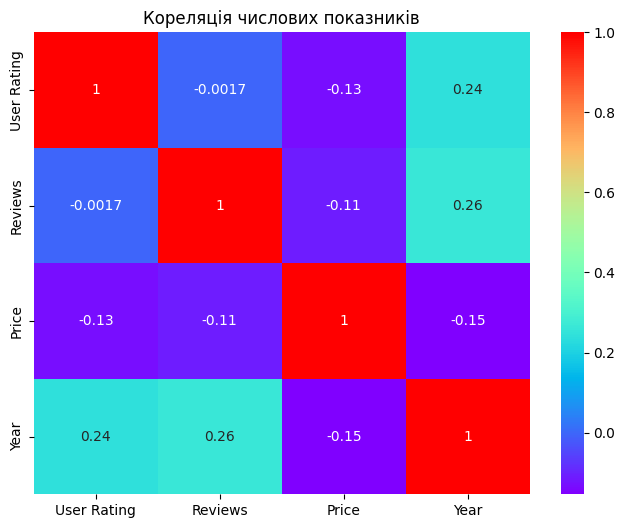

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="rainbow")
plt.title("Кореляція числових показників")
plt.show()

Обчислити середнє значення за стовпцями

In [34]:
print("Середній рейтинг:", df["User Rating"].mean())
print("Середня кількість відгуків:", df["Reviews"].mean())
print("Середня ціна:", df["Price"].mean())
print("Середній рік:", df["Year"].mean())

Середній рейтинг: 4.618363636363637
Середня кількість відгуків: 11953.281818181818
Середня ціна: 13.1
Середній рік: 2014.0


In [35]:
df.groupby("Genre")[["User Rating", "Reviews", "Price"]].mean()

,User Rating,Reviews,Price
Genre,,,
Fiction,4.648333,15683.791667,10.850000
Non Fiction,4.595161,9065.145161,14.841935


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [36]:
print("Стандартне відхилення рейтингу:", df["User Rating"].std())
print("Стандартне відхилення кількості відгуків:", df["Reviews"].std())
print("Стандартне відхилення ціни:", df["Price"].std())
print("Стандартне відхилення року:", df["Year"].std())

Стандартне відхилення рейтингу: 0.22698036502519578
Стандартне відхилення кількості відгуків: 11731.132017431895
Стандартне відхилення ціни: 10.84226197842238
Стандартне відхилення року: 3.165156384169307


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [38]:
print("Мінімальний рейтинг:", df["User Rating"].min())
print("Максимальний рейтинг:", df["User Rating"].max())
print("Мінімальна ціна:", df["Price"].min())
print("Максимальна ціна:", df["Price"].max())
print("Найменше відгуків:", df["Reviews"].min())
print("Найбільше відгуків:", df["Reviews"].max())

Мінімальний рейтинг: 3.3
Максимальний рейтинг: 4.9
Мінімальна ціна: 0
Максимальна ціна: 105
Найменше відгуків: 37
Найбільше відгуків: 87841


In [39]:
df[df["User Rating"] == df["User Rating"].max()][["Name", "Author", "User Rating", "Genre"]]

,Name,Author,User Rating,Genre
40,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,4.9,Fiction
41,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,4.9,Fiction
81,Dog Man and Cat Kid: From the Creator of Capta...,Dav Pilkey,4.9,Fiction
82,Dog Man: A Tale of Two Kitties: From the Creat...,Dav Pilkey,4.9,Fiction
83,Dog Man: Brawl of the Wild: From the Creator o...,Dav Pilkey,4.9,Fiction
84,Dog Man: Brawl of the Wild: From the Creator o...,Dav Pilkey,4.9,Fiction
85,Dog Man: Fetch-22: From the Creator of Captain...,Dav Pilkey,4.9,Fiction
86,Dog Man: For Whom the Ball Rolls: From the Cre...,Dav Pilkey,4.9,Fiction
87,Dog Man: Lord of the Fleas: From the Creator o...,Dav Pilkey,4.9,Fiction
146,"Goodnight, Goodnight Construction Site (Hardco...",Sherri Duskey Rinker,4.9,Fiction


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

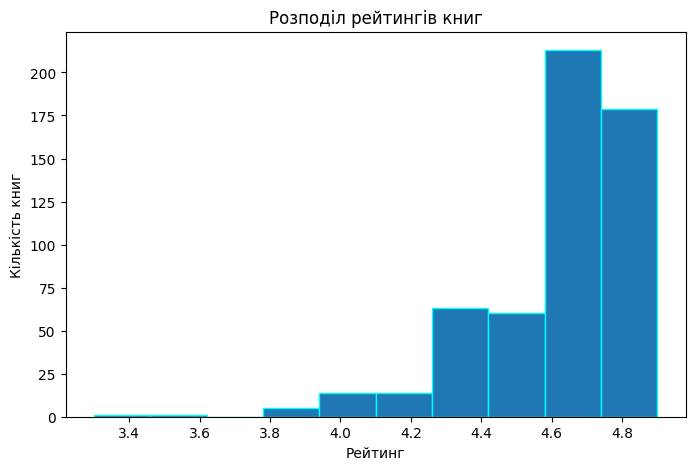

In [41]:
plt.figure(figsize=(8, 5))
plt.hist(df["User Rating"], bins=10, edgecolor="cyan")
plt.xlabel("Рейтинг")
plt.ylabel("Кількість книг")
plt.title("Розподіл рейтингів книг")
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [19]:
genre_share = df["Genre"].value_counts(normalize=True) * 100
print(genre_share)

Genre
Non Fiction    56.363636
Fiction        43.636364
Name: proportion, dtype: float64


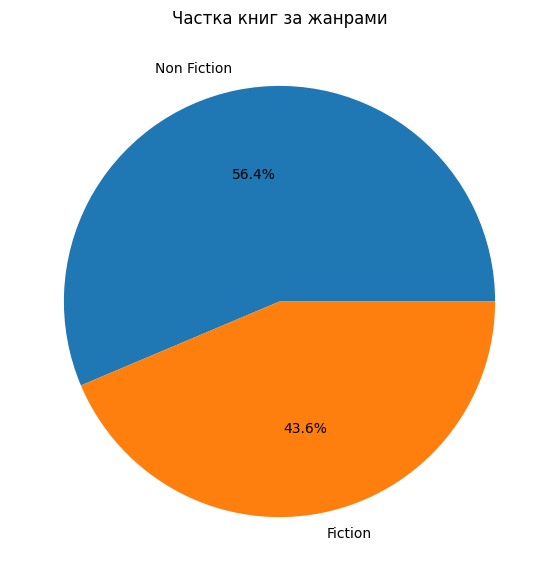

In [42]:
plt.figure(figsize=(7, 7))
plt.pie(genre_share, labels=genre_share.index, autopct="%.1f%%")
plt.title("Частка книг за жанрами")
plt.show()

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

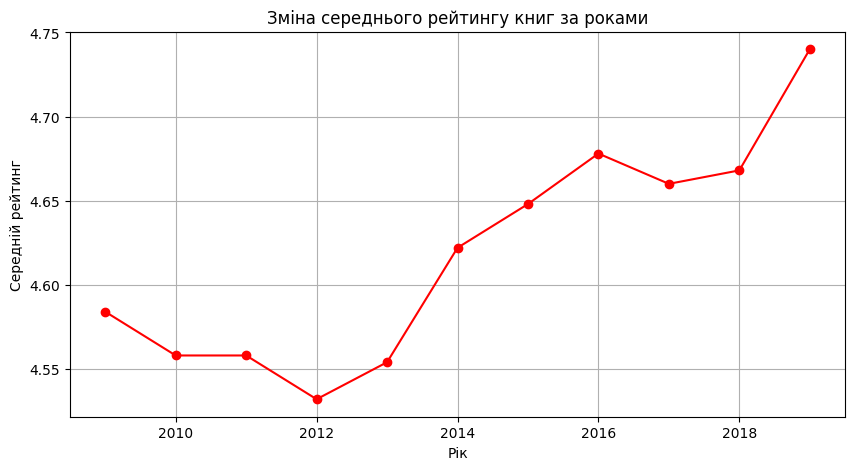

In [44]:
year_rating = df.groupby("Year")["User Rating"].mean()

plt.figure(figsize=(10, 5))
plt.plot(year_rating.index, year_rating.values, marker="o", c = "r")
plt.xlabel("Рік")
plt.ylabel("Середній рейтинг")
plt.title("Зміна середнього рейтингу книг за роками")
plt.grid(True)
plt.show()

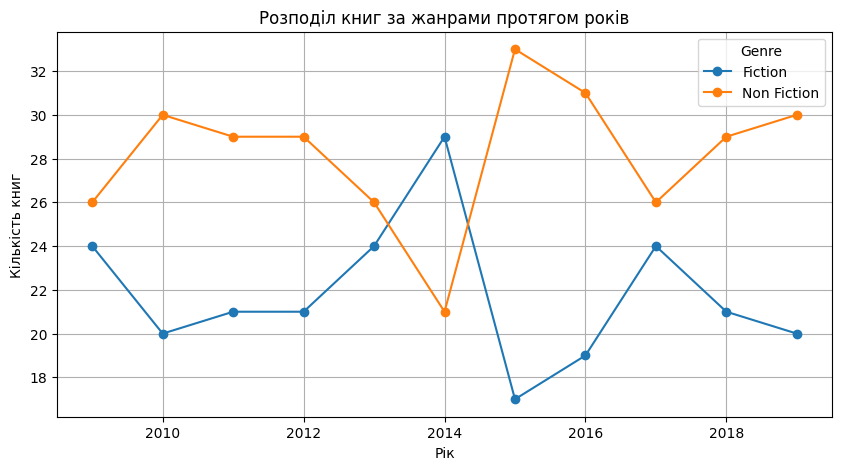

In [45]:
genre_year = pd.crosstab(df["Year"], df["Genre"])

genre_year.plot(figsize=(10, 5), marker="o")
plt.xlabel("Рік")
plt.ylabel("Кількість книг")
plt.title("Розподіл книг за жанрами протягом років")
plt.grid(True)
plt.show()

In [23]:
print("Кількість книг:", len(df))
print("Середній рейтинг:", round(df["User Rating"].mean(), 2))
print("Середня ціна:", round(df["Price"].mean(), 2))
print("Найпоширеніший жанр:", df["Genre"].mode()[0])
print("Найбільша кількість відгуків:", df["Reviews"].max())

Кількість книг: 550
Середній рейтинг: 4.62
Середня ціна: 13.1
Найпоширеніший жанр: Non Fiction
Найбільша кількість відгуків: 87841
